In [1]:
from build_fingerprints import fft, image_paths, load_shell, pca, write_outputs, reconstruct_shell
from pathlib import Path

images = image_paths(Path("../dataset"))
images[:5]

[PosixPath('../dataset/Aandara_consociata_1_A.jpg'),
 PosixPath('../dataset/Abida_polyodon_1_A.jpg'),
 PosixPath('../dataset/Abida_secale_1_A.jpg'),
 PosixPath('../dataset/Abra_alba_1_A.jpg'),
 PosixPath('../dataset/Abra_longicallus_1_A.jpg')]

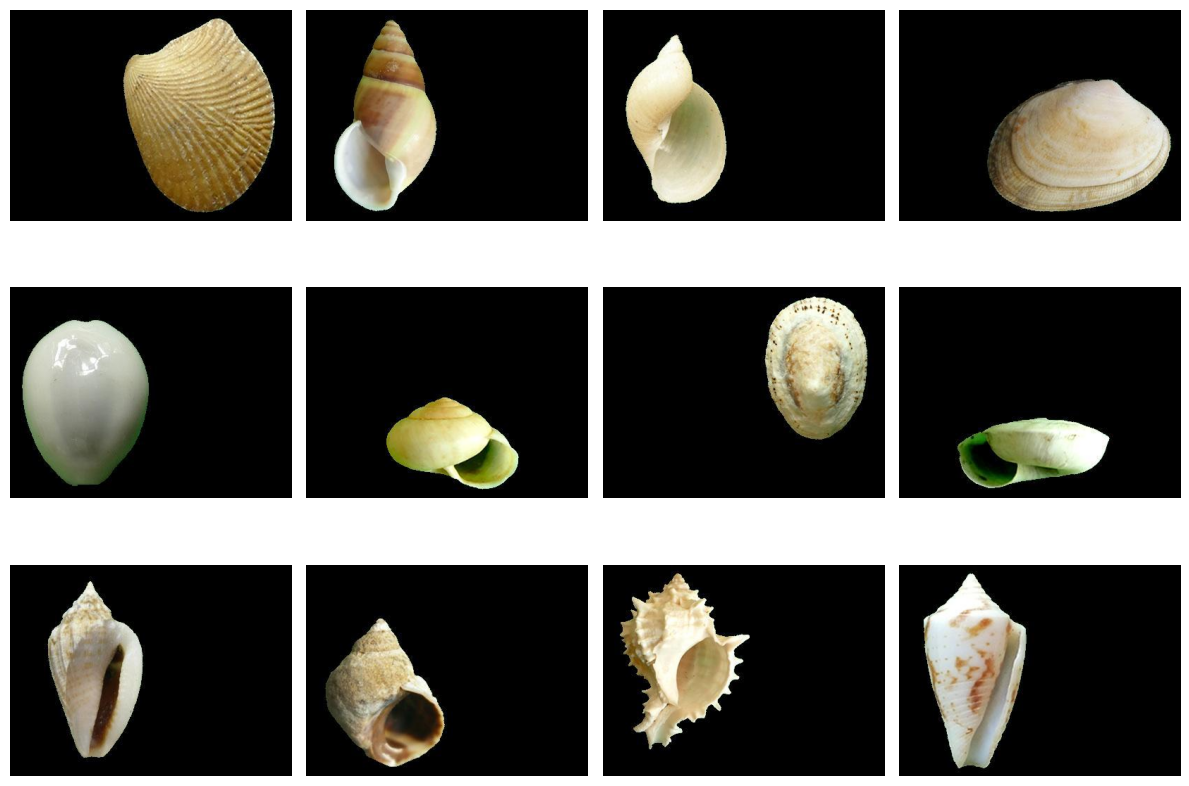

In [2]:
from matplotlib import pyplot as plt
import numpy as np

# images_under_test = np.random.choice(images, 12, replace=False)

# Good seed
images_under_test = ["../dataset/Acila_divaricata_7_A.jpg", "../dataset/Amphidromus_basilanensis_14_A.jpg", "../dataset/Radix_acuminate_1_A.jpg", "../dataset/Venerupis_aspera_2_A.jpg", "../dataset/Errosaria_obvelata_3_A.jpg", "../dataset/Bradybaena_similaris_4_A.jpg", "../dataset/Scutellastra_laticostata_5_A.jpg", "../dataset/Laeocathaica_prionotropis_6_A.jpg", "../dataset/Eucithara_marginelloides_1_A.jpg", "../dataset/Nodilittorina_radiata_7_A.jpg", "../dataset/Hexaplex_erythrostomus_1_A.jpg", "../dataset/Conus_acutimarginatus_4_A.jpg"]


fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, image in zip(axes.flatten(), images_under_test):
    img = plt.imread(image)
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

/opt/homebrew/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


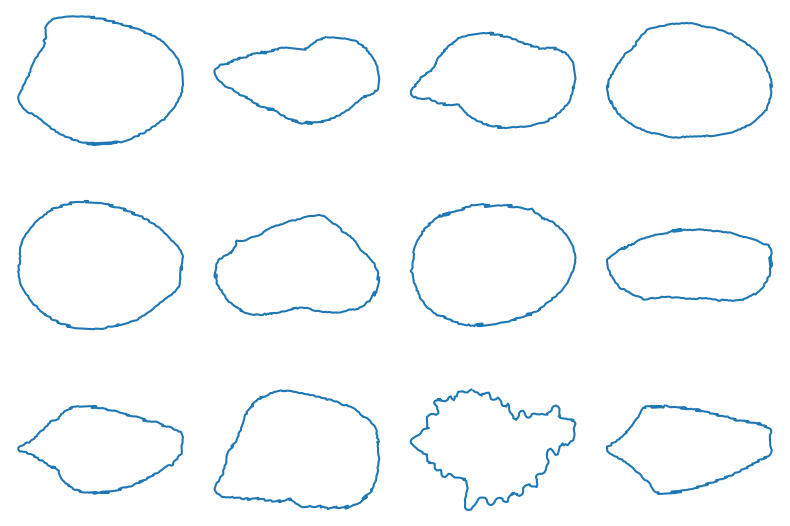

In [3]:
loaded_shells = [load_shell(image_path, 256, debug_info=True) for image_path in images_under_test]
contours = [shell for shell, debug in loaded_shells]
debug_infos = [debug for shell, debug in loaded_shells]

fig, axes = plt.subplots(3, 4, figsize=(8, 6))

for ax, points in zip(axes.ravel(), contours):
    ax.plot(points[:, 0], points[:, 1])
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()


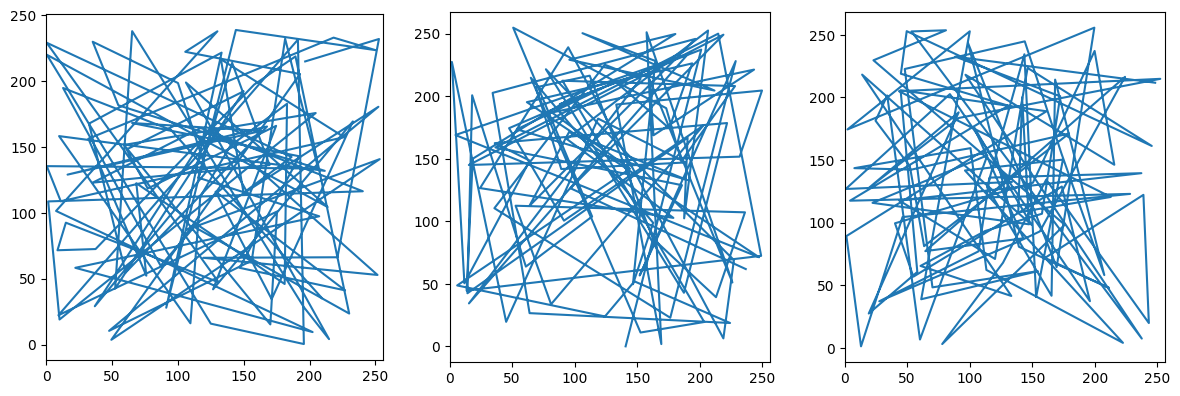

In [22]:
# Let's generate three random shells (random points)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax in axes:
    random_points = np.random.rand(100, 2) * 256
    ax.plot(random_points[:, 0], random_points[:, 1])
    ax.set_aspect("equal")
    ax.set_xlim(0, 256)

fig.tight_layout()
plt.show()

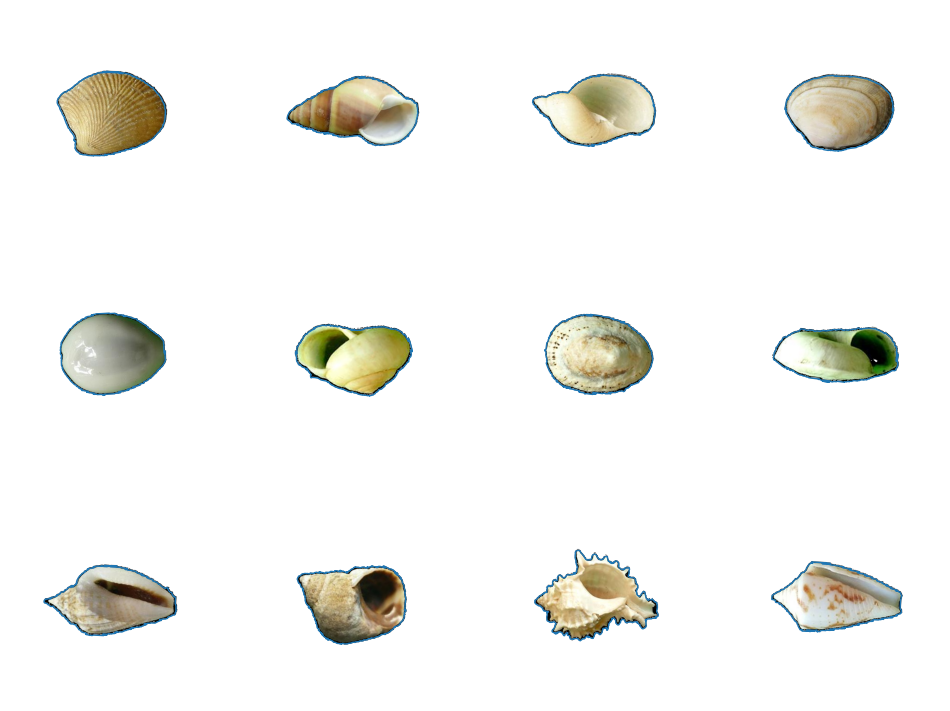

In [7]:
from matplotlib import pyplot as plt
from matplotlib.transforms import Affine2D
import numpy as np

samples = 512

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, image_path in zip(axes.flatten(), images_under_test):
    shell, debug = load_shell(Path(image_path), samples=samples, debug_info=True)

    rgba = debug["image"]
    h, w = rgba.shape[:2]

    transform = Affine2D(debug["image_to_shell"]) + ax.transData

    # show actual masked shell, normalized
    ax.imshow(
        rgba,
        origin="upper",
        extent=(0, w, h, 0),
        transform=transform,
    )

    # overlay normalized contour
    ax.plot(shell[:, 0], shell[:, 1], linewidth=1)

    ax.set_aspect("equal")
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(2.2, -2.2)  # keeps image-style y direction
    ax.axis("off")

# plt.tight_layout()
plt.show()

In [4]:
ffts = [fft(shell, 32) for shell in contours]

ffts[0].shape

(128,)

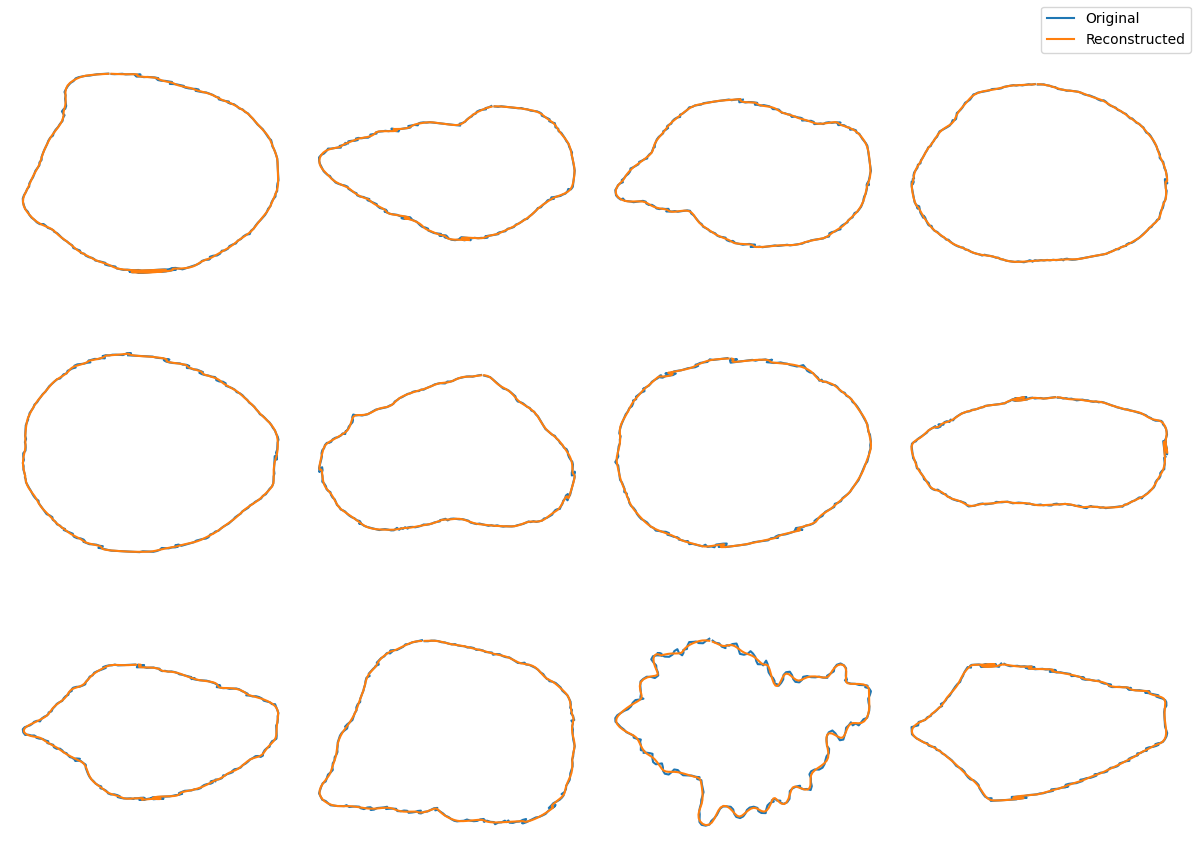

In [5]:
reconstructed_shells = [reconstruct_shell(fft, samples=256) for fft in ffts]

# plt.plot(contours[0][:, 0], contours[0][:, 1], label="original")
# plt.plot(reconstructed[:, 0], reconstructed[:, 1], label="reconstructed")
# plt.gca().set_aspect("equal")
# plt.legend()
# plt.show()
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, shell, reconstructed in zip(
    axes.flatten(),
    contours,
    reconstructed_shells
):
    line1, = ax.plot(shell[:, 0], shell[:, 1], label="Original")
    line2, = ax.plot(reconstructed[:, 0],reconstructed[:, 1],label="Reconstructed")

    ax.set_aspect("equal")
    ax.axis("off")

fig.legend(
    [line1, line2],
    ["Original", "Reconstructed"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.transforms import Affine2D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

sample_sizes = list(range(1, 256))

fig, axes = plt.subplots(
    3, 4,
    figsize=(12, 9),
    facecolor="white"
)

axes = axes.ravel()
lines = []

label = fig.suptitle(
    "",
    fontsize=20,
    fontweight="bold",
    y=0.97
)

all_points = np.vstack([
    reconstruct_shell(f, samples=255)
    for f in ffts
])
max_extent = np.abs(all_points).max() * 1.15

for ax, debug in zip(axes, debug_infos):
    image = debug["image"]
    h, w = image.shape[:2]

    ax.imshow(
        image,
        origin="upper",
        extent=[0, w, h, 0],
        transform=Affine2D(debug["image_to_shell"]) + ax.transData,
        alpha=0.45,
        zorder=0
    )

    line, = ax.plot(
        [],
        [],
        color="black",
        lw=3,
        solid_capstyle="round",
        zorder=1
    )

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(-max_extent, max_extent)
    ax.set_ylim(-max_extent, max_extent)
    ax.set_facecolor("white")
    lines.append(line)

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.02,
    top=0.90,
    wspace=0.08,
    hspace=0.08
)

def update(frame):
    samples = sample_sizes[frame]

    for line, fingerprint in zip(lines, ffts):
        shell = reconstruct_shell(
            fingerprint,
            samples=samples
        )
        closed = np.vstack([shell, shell[0]])
        line.set_data(
            closed[:, 0],
            closed[:, 1]
        )

    label.set_text(f"{samples} samples")
    return [*lines]

anim = FuncAnimation(
    fig,
    update,
    frames=len(sample_sizes),
    interval=35,
    blit=True
)

plt.close()

HTML(anim.to_jshtml(default_mode="once"))


Animation size has reached 20997343 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


In [51]:
# Save to MP4

# from pathlib import Path
# from matplotlib.animation import FFMpegWriter, PillowWriter

# media_dir = Path("../media")
# media_dir.mkdir(exist_ok=True)

# mp4_path = media_dir / "fft_reconstruction.mp4"
# gif_path = media_dir / "fft_reconstruction.gif"

# anim.save(
#     mp4_path,
#     writer=FFMpegWriter(
#         fps=30,
#         codec="libx264",
#         extra_args=["-pix_fmt", "yuv420p", "-movflags", "+faststart"]
#     ),
#     dpi=140
# )

# anim.save(
#     gif_path,
#     writer=PillowWriter(fps=20),
#     dpi=110
# )

# print(f"MP4: {mp4_path}")
# print(f"GIF: {gif_path}")
# print("GitHub markdown:")
# print("![FFT reconstruction](media/fft_reconstruction.gif)")
# print("[MP4 video](media/fft_reconstruction.mp4)")
